# Training a Neural Network

In this homework, our objective is to implement a simple neural network from scratch, in particular, error backpropagation and the gradient descent optimization procedure. We first import some useful libraries.

In [6]:
import numpy as np
import matplotlib.pyplot as plot
%matplotlib inline
na = np.newaxis
np.random.seed(0)

We consider a two-dimensional moon dataset on which to train the network. We also create a grid dataset which we will use to visualize the decision function in two dimensions. We denote our two inputs as $x_1$ and $x_2$ and use the suffix `d` and `g` to designate the actual dataset and the grid dataset.

In [84]:
# Create a moon dataset on which to train the neural network
import sklearn, sklearn.datasets
Xd, Td = sklearn.datasets.make_moons(n_samples=100)
Xd = Xd * 2 - 1
Td = Td * 2 - 1
# Xd = (100, 2) / Td = (100,)
X1d = Xd[:, 0] # (100,)
X2d = Xd[:, 1] # (100,)

# Creates a grid dataset on which to inspect the decision function
l = np.linspace(-4, 4, 100)
X1g, X2g = np.meshgrid(l, l) # (100, 100)

The moon dataset is plotted below along with some dummy decision function $x_1+x_2=0$.

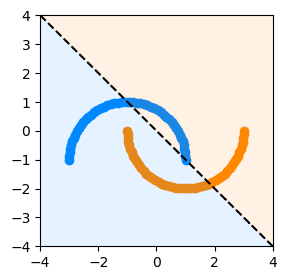

In [85]:
def plot(Yg, title=None):
    plt.figure(figsize=(3, 3))
    plt.scatter(*Xd[Td==-1].T, color='#0088FF')
    plt.scatter(*Xd[Td==1].T, color='#FF8800')
    plt.contour(X1g, X2g, Yg, levels=[0], colors='black', linestyles='dashed')
    plt.contourf(X1g, X2g, Yg, levels=[-100, 0, 100], colors=['#0088FF','#FF8800'], alpha=0.1)
    if title is not None: plt.title(title)
    plt.show()
    
plot(X1g + X2g) # plot the dummy decision function

## Part 1: Implementing Error Backpropagation (30 P)

We would like to implement the neural network with the equations:
\begin{align*}
\forall_{j=1}^{50}:~ z_j &= x_1 w_{1j} + x_2 w_{2j} + b_j\\
\forall_{j=1}^{50}:~a_j &= \max(0,z_j)\\
y &= \sum_{j=1}^{50} a_j v_j
\end{align*}
where $x_1,x_2$ are the two input variables and $y$ is the output of the network. The parameters of the neural network are initialized randomly using the normal distributions $w_{ij} \sim \mathcal{N}(\mu=0,\sigma^2=1/2)$, $b_{j} \sim \mathcal{N}(\mu=0,\sigma^2=1)$, $v_{j} \sim \mathcal{N}(\mu=0,\sigma^2=1/50)$. The following code initializes the parameters of the network and implements the forward pass defined above. The neural network is composed of 50 neurons.

In [101]:
NH = 50

W = np.random.normal(0, 1/2.0**.5, [2, NH]) # (2, 50)
B = np.random.normal(0, 1, [NH]) # (50,)
V = np.random.normal(0, 1/NH**.5, [NH]) # (50,)

def forward(X1, X2):
    X = np.array([X1.flatten(), X2.flatten()]).T # Convert meshgrid into dataset
    Z = X.dot(W) + B
    A = np.maximum(0, Z)
    Y = A.dot(V)
    return Y.reshape(X1.shape) # Reshape output into meshgrid

We now consider the task of training the neural network to classify the data. For this, we define the error function:
$$
\mathcal{E}(\theta) = \frac1N \sum_{k=1}^N \max(0,-y^{(k)} t^{(k)})
$$
where $N$ is the number of data points, $y$ is the output of the network and $t$ is the label.

**Task:**

 * **Complete the function below so that it returns the gradient of the error w.r.t. the parameters of the model.**

In [97]:
def backprop(X1, X2, T):
    # X1, X2, T = (100,) / W = (2, 50) / B, V = (50,)
    N = len(X1) # n_samples = 100
    X = np.array([X1.flatten(), X2.flatten()]).T # (100, 2)

    # Compute activations
    Z = X @ W + B # (100, 50)
    A = np.maximum(0, Z) # (100, 50)
    Y = A @ V # (100,)
    
    # Compute backward pass
    DY = (-Y * T>0) * (-T) # (100,)
    DZ = np.outer(DY, V) * (Z>0) # (100, 50)
    
    # Compute parameter gradients (averaged over the whole dataset)
    DV = (A.T @ DY) / N # (50,)
    DB = np.mean(DZ, axis=0) # (50,)
    DW = (X.T @ DZ) / N # (2, 50)
    
    return DW, DB, DV

## Exercise 2: Training with Gradient Descent (20 P)

We would like to use error backpropagation to optimize the parameters of the neural network. The code below optimizes the network for $128$ iterations and at some chosen iterations plots the decision function along with the current error.

**Task:**
 * **Complete the procedure above to perform at each iteration a step along the gradient in the parameter space. A good choice of learning rate is $\eta=0.1$.**

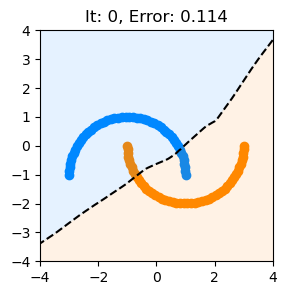

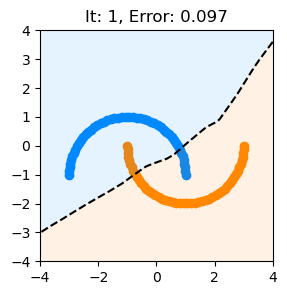

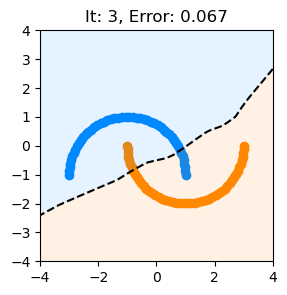

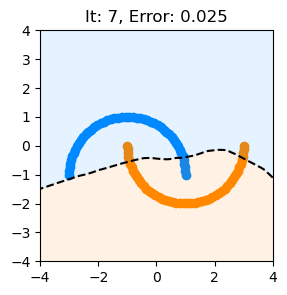

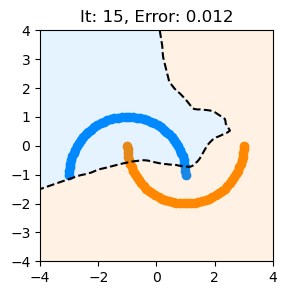

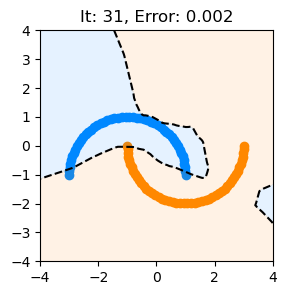

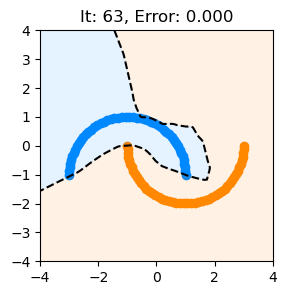

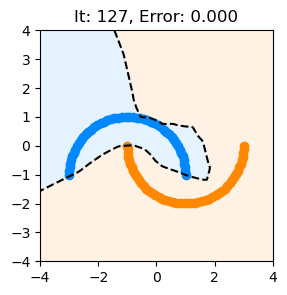

In [102]:
for i in range(128):
    
    DW, DB, DV = backprop(X1d, X2d, Td)
        
    lr = 0.1
    W = W - lr * DW
    B = B - lr * DB
    V = V - lr * DV
    
    if i in [0, 1, 3, 7, 15, 31, 63, 127]:
        Yg = forward(X1g, X2g)
        Yd = forward(X1d, X2d)
        Ed = np.maximum(0, -Yd * Td).mean()        
        plot(Yg, title="It: %d, Error: %.3f"%(i, Ed))